In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs

In [2]:
plt.style.use("~/nice.mplstyle")

In [3]:
ds = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/observations/obs_locations.nc")

In [4]:
hrrr = xr.open_zarr("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/hrrr-forecasts-vs-hrrr-analysis/hrrr.forecasts.zarr")

/tmp/ipykernel_888683/347163027.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  hrrr = xr.open_zarr("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/hrrr-forecasts-vs-hrrr-analysis/hrrr.forecasts.zarr")


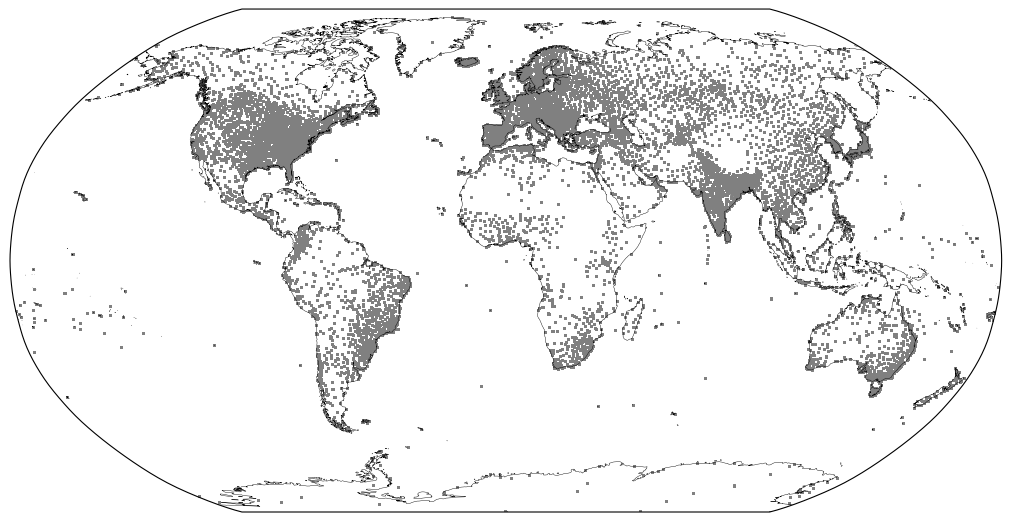

In [14]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.Robinson()})
ax.scatter(
    ds.LON,
    ds.LAT,
    s=10,
    color="gray",
    transform=ccrs.PlateCarree(),
    marker='.',
    label=f"{len(ds.obs)}",
)
ax.coastlines(resolution="50m")
fig.savefig(f"global_obs_{ds.window_start[:10]}.jpeg", bbox_inches="tight", dpi=300)

In [15]:
usds = ds.where(
    (ds.LON+360 < 310) & 
    (ds.LON+360 > 225) &
    (ds.LAT < 55) &
    (ds.LAT > 20),
)

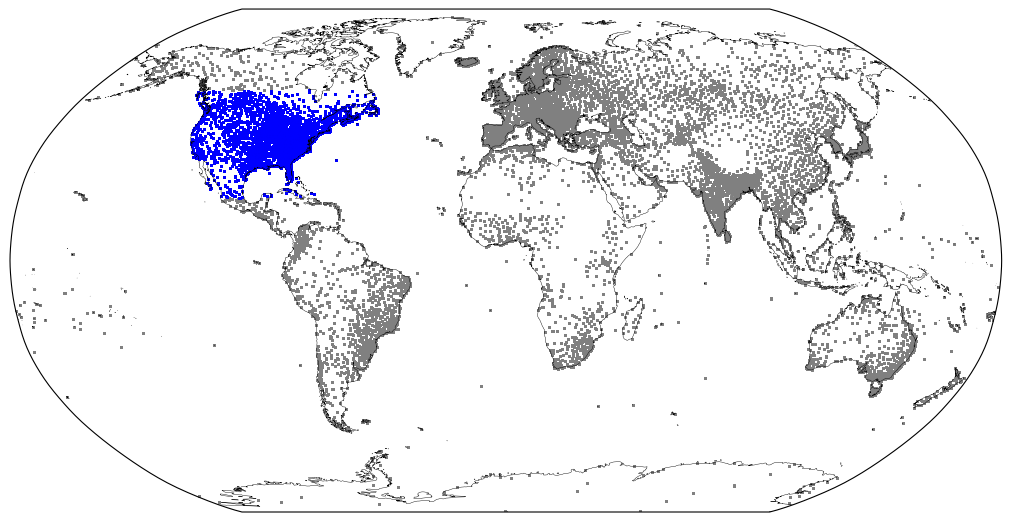

In [16]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.Robinson()})

for xds, color in zip([ds, usds], ["gray", "blue"]):
    ax.scatter(
        xds.LON,
        xds.LAT,
        s=10,
        color=color,
        transform=ccrs.PlateCarree(),
        marker='.',
    )

ax.coastlines(resolution="50m")
fig.savefig(f"usglobal_obs_{ds.window_start[:10]}.jpeg", bbox_inches="tight", dpi=300)

In [17]:
eurods = ds.where(
    (ds.LON < 65) & 
    (ds.LON > -25) &
    (ds.LAT < 75) &
    (ds.LAT > 35),
)

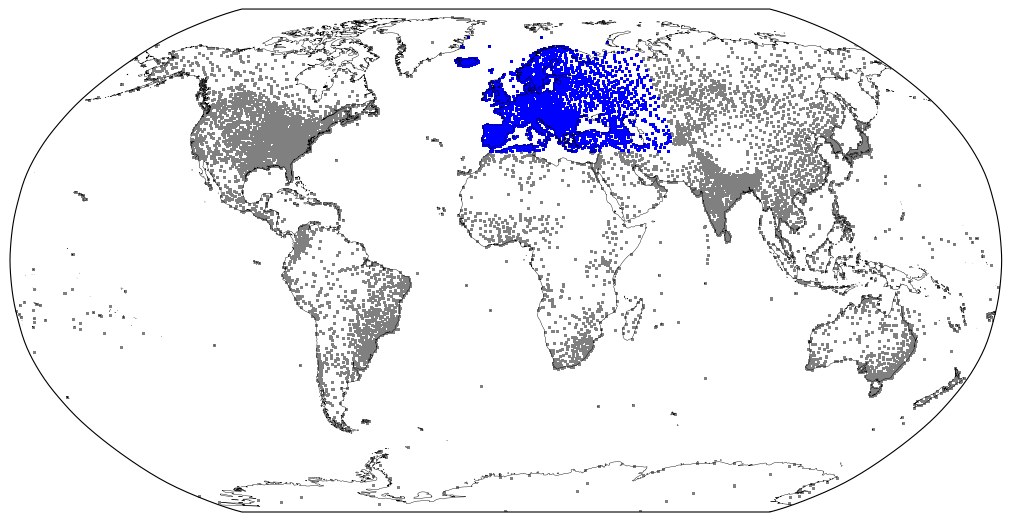

In [21]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.Robinson()})
for xds, color in zip([ds, eurods], ["gray", "blue"]):
    ax.scatter(
        xds.LON,
        xds.LAT,
        s=10,
        color=color,
        transform=ccrs.PlateCarree(),
        marker='.',
    )

ax.coastlines(resolution="50m")
fig.savefig(f"euroglobal_obs_{ds.window_start[:10]}.jpeg", bbox_inches="tight", dpi=300)

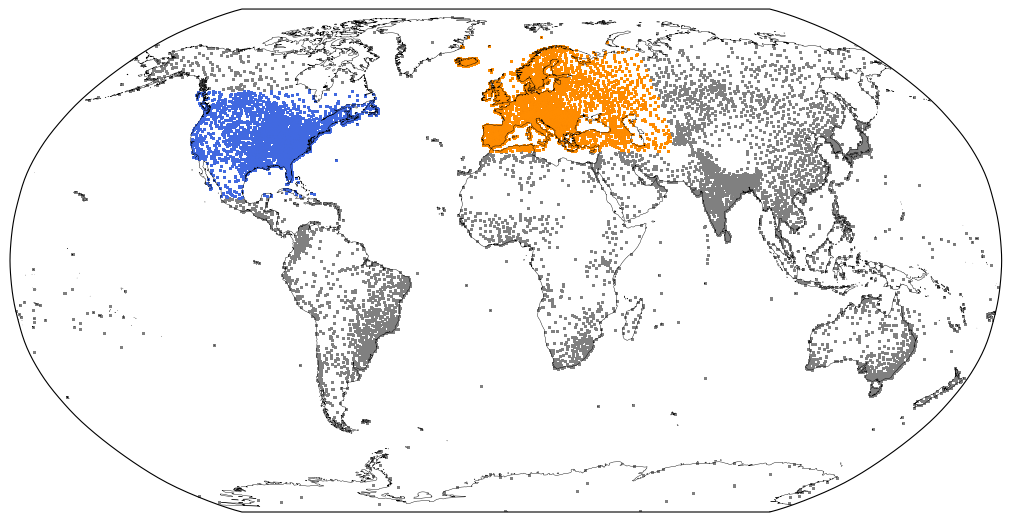

In [20]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.Robinson()})
for xds, color in zip([ds, usds, eurods], ["gray", "royalblue", "darkorange"]):
    ax.scatter(
        xds.LON,
        xds.LAT,
        s=10,
        color=color,
        transform=ccrs.PlateCarree(),
        marker='.',
    )

ax.coastlines(resolution="50m")
fig.savefig(f"eurousglobal_obs_{ds.window_start[:10]}.jpeg", bbox_inches="tight", dpi=300)

In [10]:
check = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-testing/obs-metrics/subregions.nc")

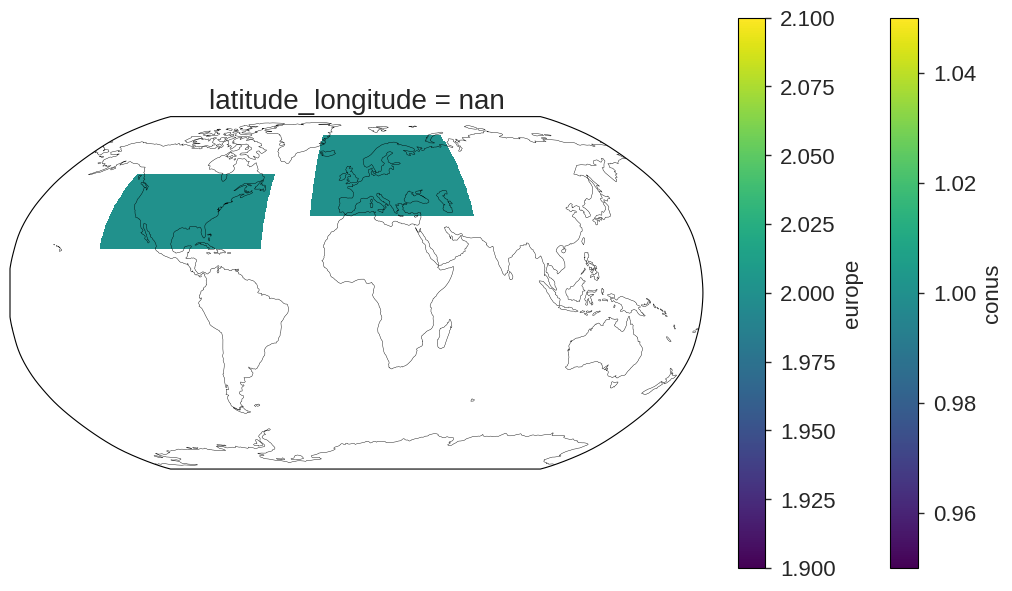

In [11]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.Robinson()})
check.conus.plot(ax=ax, transform=ccrs.PlateCarree())
(2*check.europe).plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()

## Old, using the g104, g004 grids

In [3]:
g104 = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/observations/g104/obs/20230201/06/gdas.20230201.t06z.prepbufr.nc")
g004 = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/observations/g004/obs/20230201/06/gdas.20230201.t06z.prepbufr.nc")

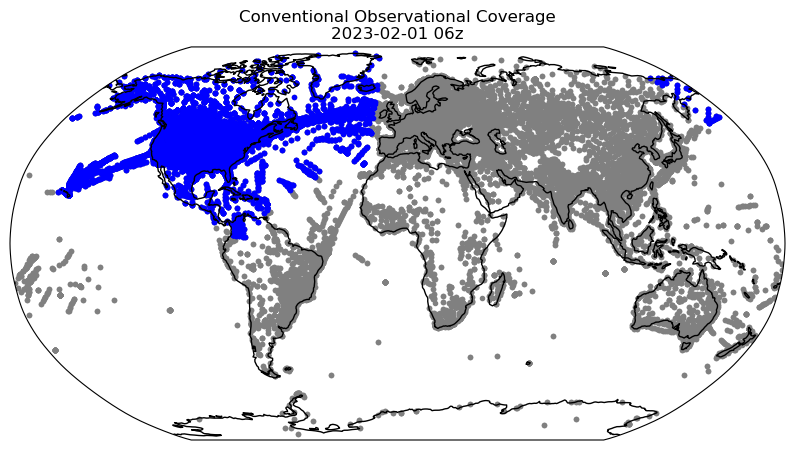

In [4]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.Robinson()})

for xds, color in zip([g004, g104], ["gray", "blue"]):
    ax.scatter(
        xds.hdr_lon,
        xds.hdr_lat,
        color=color,
        transform=ccrs.PlateCarree(),
        marker='.',
        label=f"{len(xds.nobs)}",
    )
ax.coastlines()
ax.set(title="Conventional Observational Coverage\n2023-02-01 06z")
fig.savefig(f"figures/obs_coverage.jpeg", dpi=300, bbox_inches="tight")